# A/B Test Simulator

This notebook simulates an A/B test between two webpage versions with different true conversion rates (10% vs 12%), then investigates how sample size affects a hypothesis test's ability to correctly detect that real difference.

In [2]:
import numpy as np

np.random.seed(42)

true_rate_a = 0.10
true_rate_b = 0.12

n_visitors = 1000

clicks_a = np.random.binomial(1,true_rate_a,n_visitors)
clicks_b = np.random.binomial(1,true_rate_b,n_visitors)



In [3]:
print(clicks_a.sum(),clicks_a.mean())
print(clicks_b.sum(),clicks_b.mean())

100 0.1
112 0.112


## Running a hypothesis test

A two-proportion z-test checks whether the observed difference in click rates is likely a real effect or could be explained by random chance. It returns:
- A **z-statistic**: how many standard deviations apart the two rates are
- A **p-value**: the probability of seeing a gap this large, purely by chance, if there were truly no difference between the groups

With 1000 visitors per group, this test alone was not able to confidently detect the real 2-point gap between A and B — the p-value (0.38) was far above the typical 0.05 significance threshold.

In [4]:
from statsmodels.stats.proportion import proportions_ztest
count = np.array([clicks_a.sum(),clicks_b.sum()])
nobs = np.array([n_visitors,n_visitors])

z_test,p_value = proportions_ztest(count,nobs)
print(z_test,p_value)

-0.8716548604640172 0.3833966925145821


In [5]:
def run_ab_test(n_visitors,true_rate_a=0.10,true_rate_b=0.12):
    clicks_a = np.random.binomial(1,true_rate_a,n_visitors)
    clicks_b = np.random.binomial(1,true_rate_b,n_visitors)

    count =np.array([clicks_a.sum(),clicks_b.sum()])
    nobs = np.array([n_visitors,n_visitors])

    z_test,p_value = proportions_ztest(count,nobs)
    return p_value

In [6]:
print(run_ab_test(1000))

0.559531473671846


## Does sample size matter?

The true difference between A and B never changes - but can a larger sample make that real difference easier to detect? Testing across a range of sample sizes, from 100 to 50,000 visitors per group.

In [9]:
sample_sizes = [100,500,1000,5000,10000,20000,50000]
p_values = []

for n in sample_sizes:
    p=run_ab_test(n)
    p_values.append(p)
  
print(p_values)

[np.float64(1.0), np.float64(0.1871219454161075), np.float64(0.5123999635402045), np.float64(0.0020242160167181786), np.float64(3.8132480901776377e-08), np.float64(2.679632578438321e-17), np.float64(4.623154519921736e-18)]


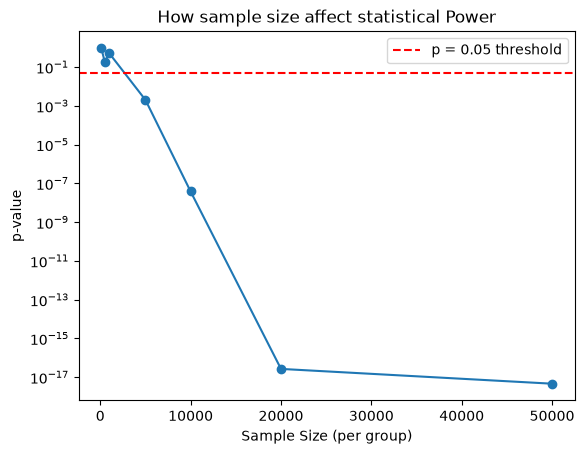

In [10]:
import matplotlib.pyplot as plt
plt.plot(sample_sizes,p_values,marker='o')
plt.axhline(y=0.05,color='red',linestyle='--',label = 'p = 0.05 threshold')
plt.xlabel("Sample Size (per group)")
plt.ylabel('p-value')
plt.yscale('log')
plt.legend()
plt.title("How sample size affect statistical Power")
plt.show()

## Conclusion

The same real 2-percentage-point gap between Version A and Version B went from statistically undetectable (p > 0.05) at small sample sizes to overwhelmingly significant (p < 10^-17) at large sample sizes - even though the underlying true rates never changed anywhere in this experiment.

This demonstrates that a hypothesis test's ability to detect a real effect depends heavily on sample size, not just on whether an effect genuinely exists. A "non-significant" result with a small sample does not necessarily mean there's no real difference - it may simply mean there wasn't enough data to detect it.